![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
#instalar keras
!pip install keras

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 17.5 MB/s eta 0:00:00


In [6]:
#instalar tensorflow
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
    --------------------------------------- 6.3/350.9 MB 29.7 MB/s eta 0:00:12
   - -------------------------------------- 14.7/350.9 MB 35.5 MB/s eta 0:00:10
   -- ------------------------------------- 25.7/350.9 MB 40.7 MB/s eta 0:00:08
   ---- ----------------------------------- 36.7/350.9 MB 43.2 MB/s eta 0:00:08
   ----- ---------------------------------- 46.7/350.9 MB 45.0 MB/s eta 0:00:07
   ------ --------------------------------- 56.9/350.9 MB 44.8 MB/s eta 0:00:07
   ------- -------------------------------- 67.1/350.9 MB 45.5 MB/s eta 0:00:07
   -------- ------------------------------- 77.6/350.9 MB 45.8 MB/s eta 0:00:06
   ---------- ----------------------------- 88.3/350.9 MB 46.2 MB/s eta 0:00:06
   ----------- ---------------------------- 98.3/350.9 MB 46.5 MB/s eta 0:00:06
   ------------ -------------------------- 110.6/350

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.1.1 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [24]:
#instalar livelossplot
!pip install livelossplot

Defaulting to user installation because normal site-packages is not writeable


In [1]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [2]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


In [20]:
data.shape

(500, 8)

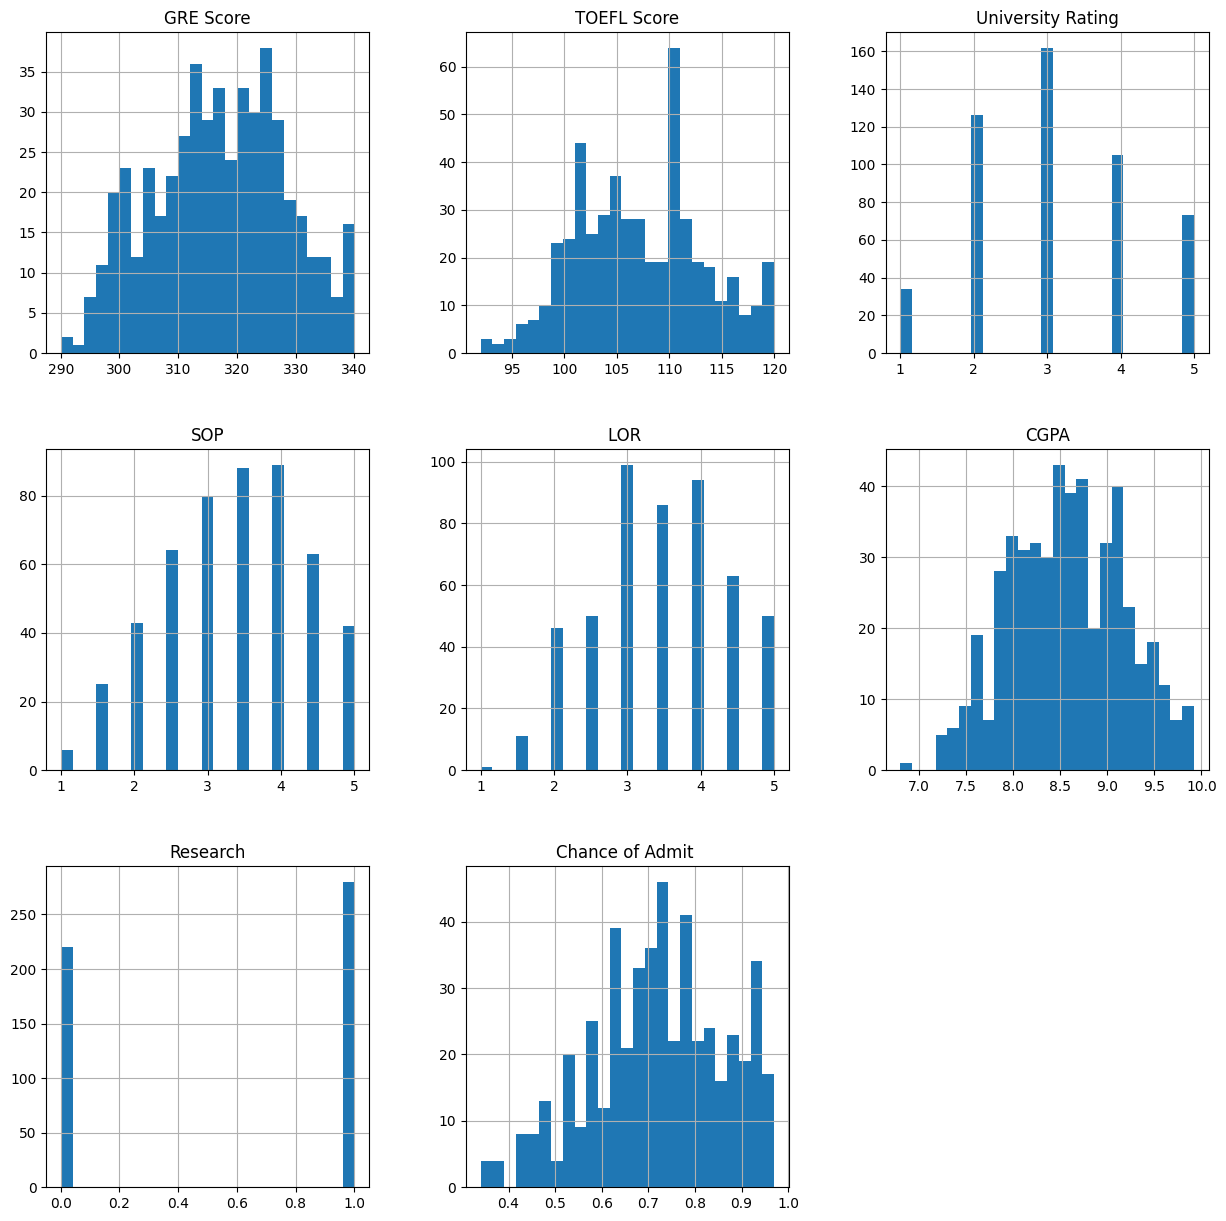

In [8]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [68]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)  
# Definición de variable de interés (y) 'Chance of Admit '
Y = data[data.columns[-1]]

In [69]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [70]:
# normalización de los datos: solo lo hacemos en entrenamiento para evitar leakage
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)

#para no convertir a dataframe , pase a np.array los valores de Y
# Convertir a numpy y asegurar que sea una columna limpia
yTrain = np.array(yTrain).reshape(-1, 1)
yTest = np.array(yTest).reshape(-1, 1)


In [71]:
if len(yTrain.shape) > 1:
    output_var = yTrain.shape[1]
else:
    output_var = 1
print(output_var, ' output variables')    

1  output variables


In [72]:
len(xTrain.shape)
# Definición de dimensiones de entrada, varaibles predictoras
dims = xTrain.shape[1]
print(dims, 'input variables')

7 input variables


In [73]:
from keras import backend as K

K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()
# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(output_var, input_shape=(dims,)))

# Impresión de la arquitectura de la red neuronal
print(model.summary())

C:\Users\johmeneses\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

None


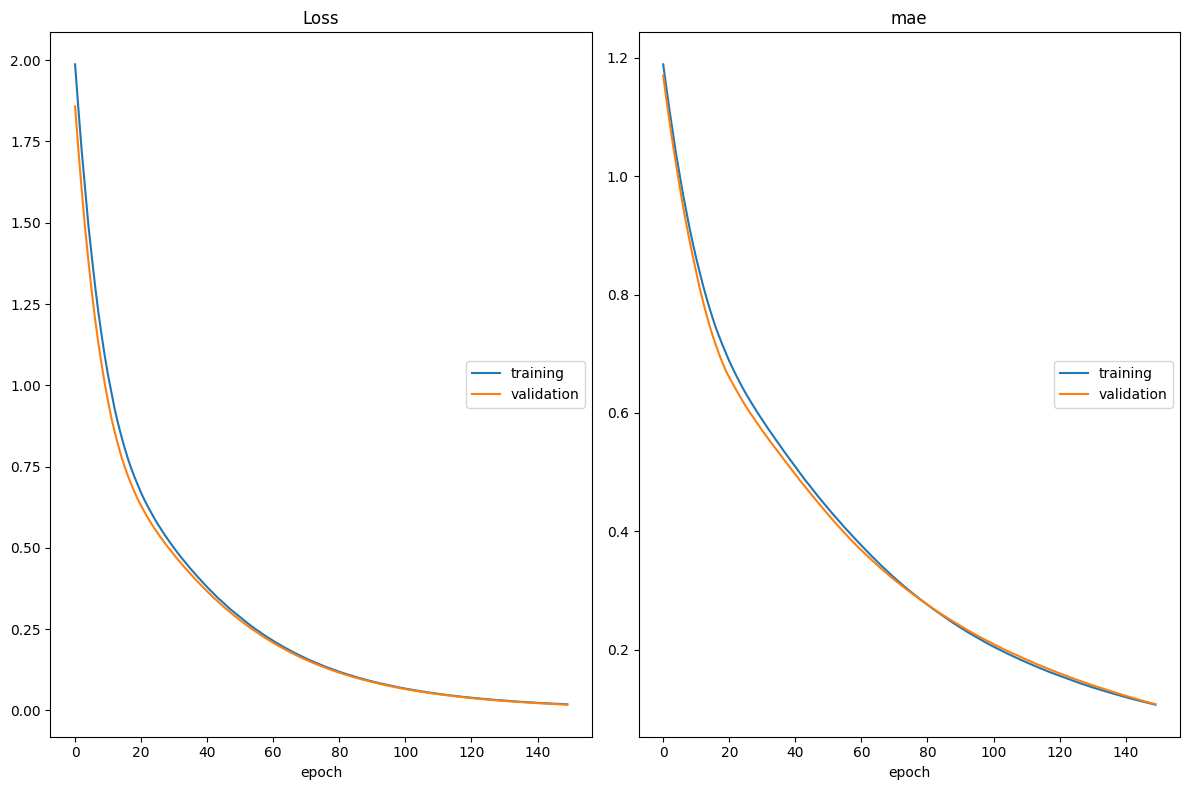

Loss
	training         	 (min:    0.019, max:    1.987, cur:    0.019)
	validation       	 (min:    0.018, max:    1.858, cur:    0.018)
mae
	training         	 (min:    0.107, max:    1.189, cur:    0.107)
	validation       	 (min:    0.108, max:    1.170, cur:    0.108)
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0189 - mae: 0.1070 - val_loss: 0.0177 - val_mae: 0.1079


In [74]:
from livelossplot import PlotLossesKeras
from tensorflow.keras.callbacks import EarlyStopping

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='Adam', loss='mean_squared_error', metrics=['mae'])

#definicion de early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model.fit(xTrain, yTrain,
          verbose=1, 
          epochs=150, 
          validation_data=(xTest, yTest),
          callbacks=[early_stop, PlotLossesKeras()])

In [75]:
# Evaluar el modelo con los datos de prueba
evaluacion = model.evaluate(xTest, yTest, verbose=0)

print(f"Desempeño del Modelo:")
print(f"MSE: {evaluacion[0]:.4f}")
print(f"MAE: {evaluacion[1]:.4f}")


Desempeño del Modelo:
MSE: 0.0177
MAE: 0.1079


In [77]:
evaluacion

[0.017740409821271896, 0.10786587744951248]

- Debido a la pequeña cantidad de datos, se propone una arquitectura sencilla, con valor de epoca de 150 y el optimizador Adam por su capacidad de ajustar la tasa de aprendizaje de forma dinamica.
- El uso de EarlyStopping se propone para controlar que se detenga en el momento que ya no hay mejoras en la perdida, sin embargo logra llegar a las 150 epocas propuestas
- La diferencia entre los valores de training y validation es minima. Esto significa que no tiene overfitting el modelo generado.
- Las cifras finales del MSE y MAE son buenas (inferiores a 0.10), significa que en promedio, el proceso de admision falla en un 4% aprox.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [78]:
K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(16, input_shape=(dims,),activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(output_var, activation='sigmoid'))

# Impresión de la arquitectura de la red neuronal
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

None


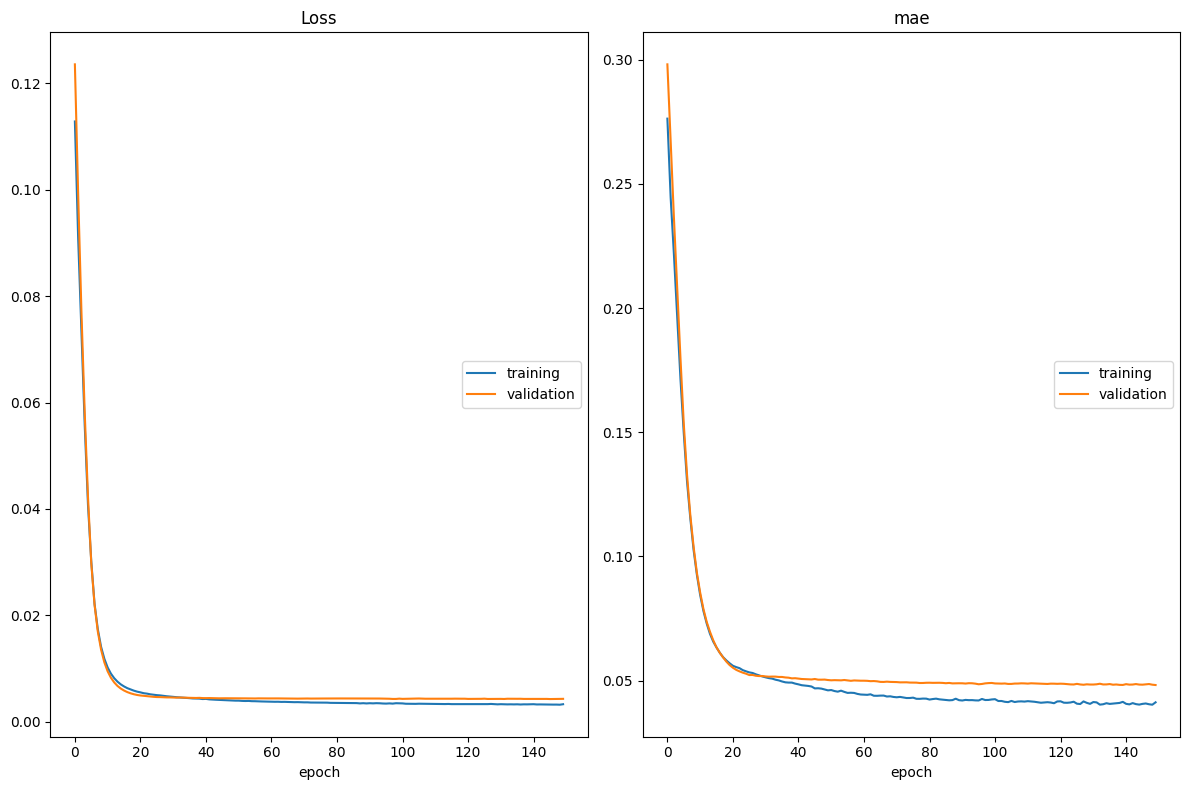

Loss
	training         	 (min:    0.003, max:    0.113, cur:    0.003)
	validation       	 (min:    0.004, max:    0.124, cur:    0.004)
mae
	training         	 (min:    0.040, max:    0.276, cur:    0.041)
	validation       	 (min:    0.048, max:    0.298, cur:    0.048)
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0033 - mae: 0.0412 - val_loss: 0.0043 - val_mae: 0.0482


In [79]:
# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='Adam', loss='mean_squared_error', metrics=['mae'])

# Separación de datos de entrenamiento para considerar un set de validación durante entrenamiento
X_train, X_val, Y_train, Y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

# Entrenamiento de la red neuronal con 150 epocas
model.fit(X_train, Y_train,
          verbose= 1,
          validation_data = (X_val, Y_val),
          epochs=150, 
          callbacks=[PlotLossesKeras()])

In [80]:
# Evaluar el modelo con los datos de prueba
evaluacion2 = model.evaluate(X_val, Y_val, verbose=0)

print(f"Desempeño del Modelo:")
print(f"MSE: {evaluacion2[0]:.4f}")
print(f"MAE: {evaluacion2[1]:.4f}")

Desempeño del Modelo:
MSE: 0.0043
MAE: 0.0482


- La seleccion del numero de neuronas se hace a partir del numero de entradas (un poco mas del doble = 16), para la segunda capa es la mitad del anterior (8)
- Se prueba como optimizador sgd y Adam, se detuvo en epoca 14, Adam termina dando mejores desempeños, aunque no por mucho.
- Se configura activacion de salida sigmoide, para que ls predicciones siempre esten entre 0 y 1
- Su desempeño final incrementa ligeramente frente al modelo de una capa, sin embargo siguen siendo valores buenos.


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [81]:
K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model.add(Dense(16, input_shape=(dims,),activation='relu'))
Dropout(0.2),
model.add(Dense(8,activation='relu'))
Dropout(0.1),
model.add(Dense(output_var, activation='sigmoid'))

# Impresión de la arquitectura de la red neuronal
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

None


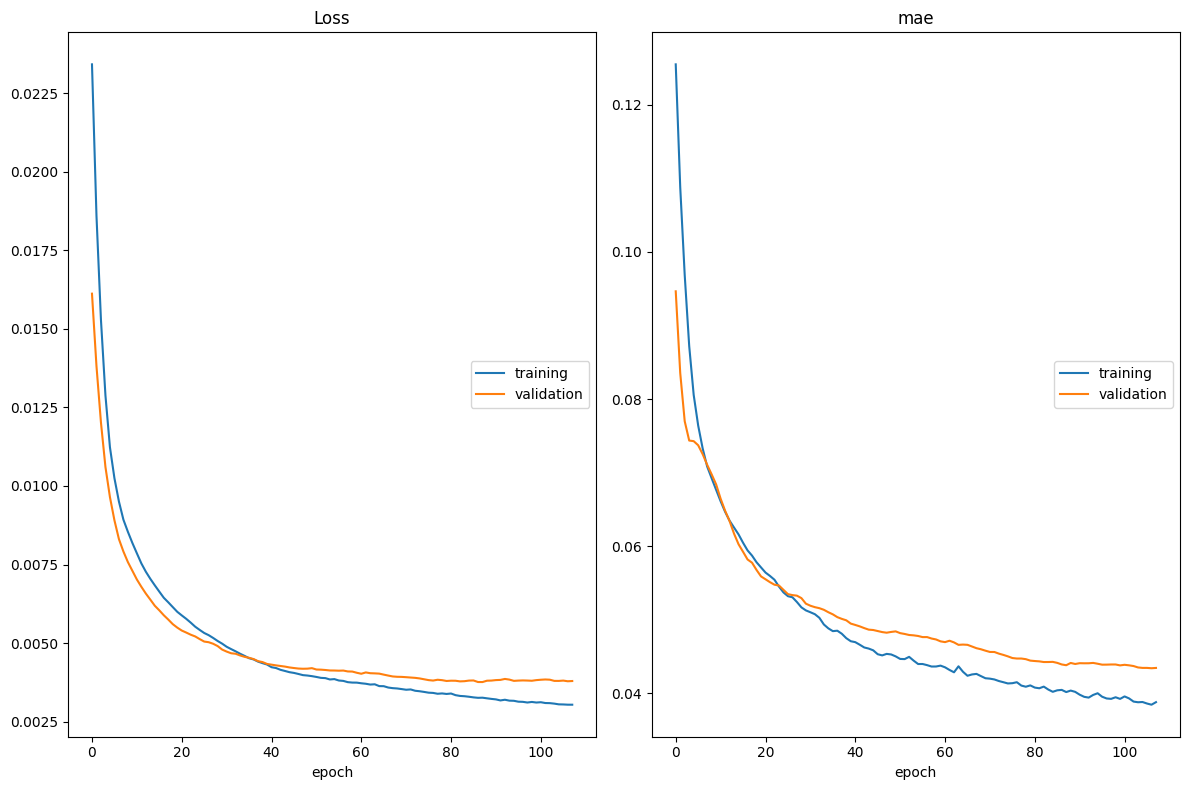

Loss
	training         	 (min:    0.003, max:    0.023, cur:    0.003)
	validation       	 (min:    0.004, max:    0.016, cur:    0.004)
mae
	training         	 (min:    0.038, max:    0.126, cur:    0.039)
	validation       	 (min:    0.043, max:    0.095, cur:    0.043)
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0030 - mae: 0.0388 - val_loss: 0.0038 - val_mae: 0.0434


In [82]:
# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='Adam', loss='mean_squared_error', metrics=['mae'])

early_stop2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Separación de datos de entrenamiento para considerar un set de validación durante entrenamiento
X_train, X_val, Y_train, Y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

# Entrenamiento de la red neuronal con 150 epocas
model.fit(X_train, Y_train,
          verbose= 1,
          validation_data = (X_val, Y_val),
          epochs=150, 
          callbacks=[early_stop2, PlotLossesKeras()])

In [83]:
# Evaluar el modelo con los datos de prueba
evaluacion3 = model.evaluate(X_val, Y_val, verbose=0)

print(f"Desempeño del Modelo:")
print(f"MSE: {evaluacion3[0]:.4f}")
print(f"MAE: {evaluacion3[1]:.4f}")

Desempeño del Modelo:
MSE: 0.0038
MAE: 0.0438


## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

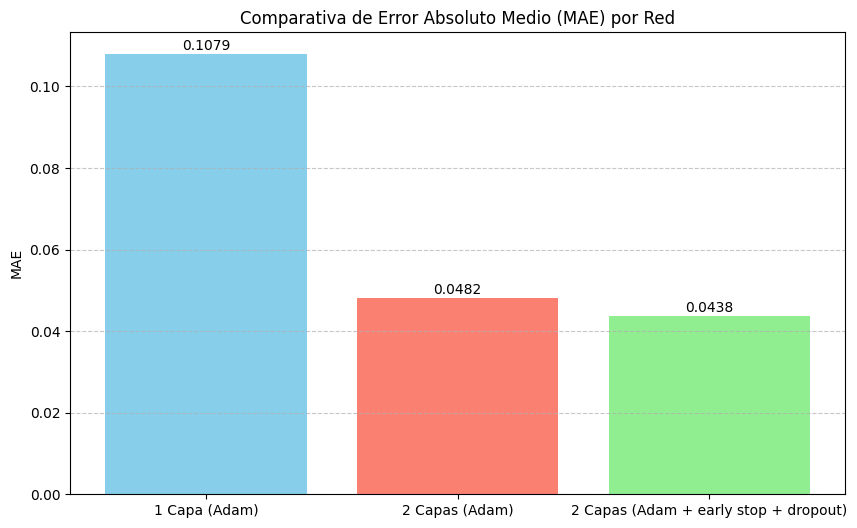

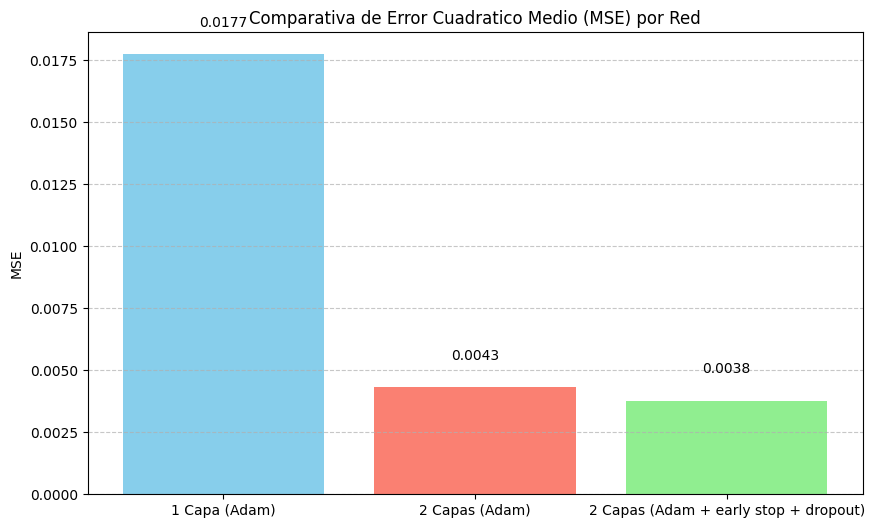

In [84]:
import matplotlib.pyplot as plt

nombres_pruebas = ['1 Capa (Adam)', '2 Capas (Adam)', '2 Capas (Adam + early stop + dropout)']
mae_valores = [evaluacion[1], evaluacion2[1], evaluacion3[1]] 
mse_valores = [evaluacion[0], evaluacion2[0], evaluacion3[0]] 

plt.figure(figsize=(10, 6))
bars = plt.bar(nombres_pruebas, mae_valores, color=['skyblue', 'salmon', 'lightgreen'])

# Añadir etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 4), ha='center')

plt.title('Comparativa de Error Absoluto Medio (MAE) por Red')
plt.ylabel('MAE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
bars = plt.bar(nombres_pruebas, mse_valores, color=['skyblue', 'salmon', 'lightgreen'])

# Añadir etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 4), ha='center', va='bottom')

plt.title('Comparativa de Error Cuadratico Medio (MSE) por Red')
plt.ylabel('MSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()